# **Tweet Sentiment Analysis**

### **Assignment 2 - Natural Language Processing - MSc. Computer Science, AUEB [2025-2026]**

> Maria Schoinaki, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> mar.schoinaki@aueb.gr

> Electra Papadopoulou, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> elec.papadopoulou@aueb.gr

> Leonidas Kontogiannis, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> leo.kontogiannis@aueb.gr

##Imports

In [ ]:
import os
import pandas as pd
import numpy as np

In [ ]:
os.environ["KAGGLE_USERNAME"] = "" #add your own username
os.environ["KAGGLE_KEY"] = "" # add your own key

In [ ]:
!pip install -q kaggle
DATA_DIR = "/content/data"
!mkdir -p $DATA_DIR

!kaggle competitions download -c twitter-sentiment-analysis2 -p $DATA_DIR --force
!unzip -qo "$DATA_DIR/twitter-sentiment-analysis2.zip" -d $DATA_DIR

!ls -lh $DATA_DIR


  0% 0.00/14.6M [00:00<?, ?B/s]
100% 14.6M/14.6M [00:00<00:00, 759MB/s]
total 48M
-rw-r--r-- 1 root root  25M Nov 28  2019 test.csv
-rw-r--r-- 1 root root 8.3M Nov 28  2019 train.csv
-rw-r--r-- 1 root root  15M Nov 28  2019 twitter-sentiment-analysis2.zip


In [ ]:
try:
    df = pd.read_csv("/content/data/train.csv")
except UnicodeDecodeError:
    df = pd.read_csv("/content/data/train.csv", encoding="ISO-8859-1")

print("Loaded CSV successfully.")
print(df.shape)
df.head()

Loaded CSV successfully.
(99989, 3)


,ItemID,Sentiment,SentimentText
0,1,0,is so sad for my APL frie...
1,2,0,I missed the New Moon trail...
2,3,1,omg its already 7:30 :O
3,4,0,.. Omgaga. Im sooo im gunna CRy. I'...
4,5,0,i think mi bf is cheating on me!!! ...


In [ ]:
# Display basic info
print("Full dataset shape:", df.shape)
print(df['Sentiment'].value_counts())

Full dataset shape: (99989, 3)
Sentiment
1    56457
0    43532
Name: count, dtype: int64


### **Exploring the Dataset**

In [ ]:
x, y = df['SentimentText'], df['Sentiment']
print(len(x))
print(len(y))

99989
99989


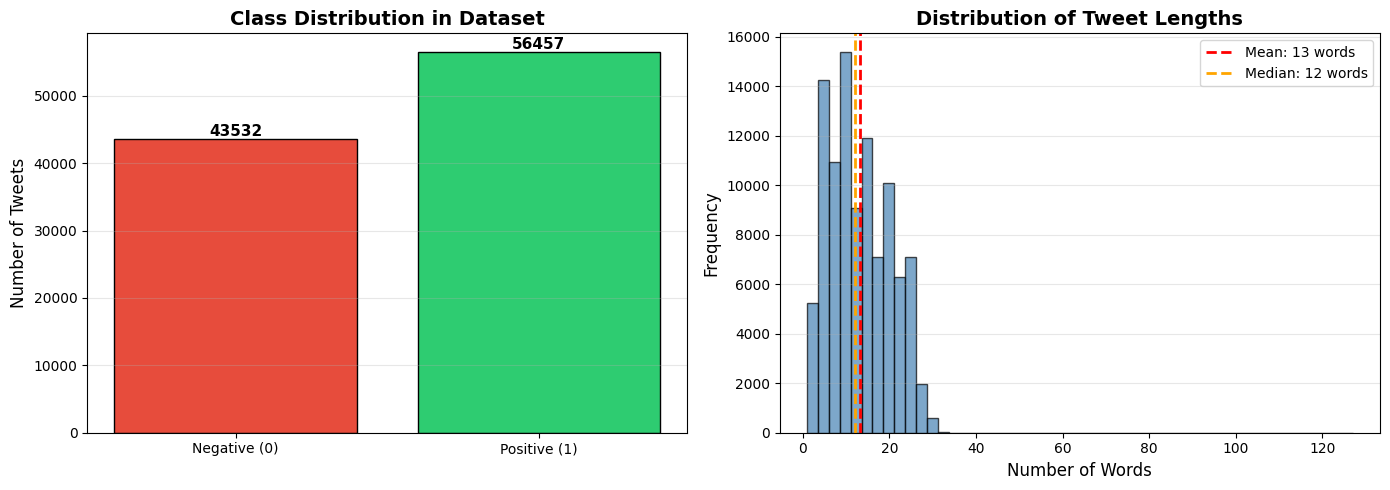

DATASET SUMMARY
Total tweets: 99989
Negative tweets: 43532 (43.5%)
Positive tweets: 56457 (56.5%)

Review Length Statistics:
  Min length: 1 words
  Max length: 127 words
  Mean length: 13.3 words
  Median length: 12.0 words
  Std deviation: 7.0 words


In [ ]:
import matplotlib.pyplot as plt

# Plot 1: Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
class_counts = np.bincount(y)
axes[0].bar(['Negative (0)', 'Positive (1)'], class_counts, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_ylabel('Number of Tweets', fontsize=12)
axes[0].set_title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
# Add count labels on bars
for i, count in enumerate(class_counts):
    axes[0].text(i, count + 20, str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Tweet Length Distribution
tweet_lengths = [len(str(tweet).split()) for tweet in x]
axes[1].hist(tweet_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(np.mean(tweet_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(tweet_lengths):.0f} words')
axes[1].axvline(np.median(tweet_lengths), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(tweet_lengths):.0f} words')
axes[1].set_xlabel('Number of Words', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Tweet Lengths', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"Total tweets: {len(x)}")
print(f"Negative tweets: {class_counts[0]} ({class_counts[0]/len(x)*100:.1f}%)")
print(f"Positive tweets: {class_counts[1]} ({class_counts[1]/len(x)*100:.1f}%)")
print(f"\nReview Length Statistics:")
print(f"  Min length: {min(tweet_lengths)} words")
print(f"  Max length: {max(tweet_lengths)} words")
print(f"  Mean length: {np.mean(tweet_lengths):.1f} words")
print(f"  Median length: {np.median(tweet_lengths):.1f} words")
print(f"  Std deviation: {np.std(tweet_lengths):.1f} words")
print("="*60)

###  **Preprocess dataset**

In [ ]:
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 56.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy
import re
from tqdm import tqdm

# Load spaCy model
nlp = spacy.load("en_core_web_sm", disable=["ner","parser"])
# disabling parser and ner may speed up processing since you only need POS + lemma

docs = []
symbol_word_pattern = re.compile(r'\s*[\@\#\&][^\s]+')
html_entity_pattern = re.compile(r'&[a-z]+;')
url_pattern = re.compile(r'https?://\S+|www\.\S+')


for doc_text in tqdm(x):
    # Remove symbol prefix words
    doc_clean = symbol_word_pattern.sub(' ', doc_text)
    # Remove HTML entities
    doc_clean = html_entity_pattern.sub(' ', doc_clean)
    #Remove URLs
    doc_clean = url_pattern.sub(' ', doc_clean)
    # Remove non-word characters (punctuation etc)
    doc_clean = re.sub(r'\W', ' ', str(doc_clean))
    # Remove single characters (optional)
    doc_clean = re.sub(r'\s+[a-zA-Z]\s+', ' ', doc_clean)
    # Collapse multiple spaces
    doc_clean = re.sub(r'\s+', ' ', doc_clean, flags=re.I)
    # Lowercase
    doc_clean = doc_clean.lower().strip()

    # Process with spaCy
    doc = nlp(doc_clean)
    tokens = []
    for token in doc:
        # filter: only alphabetic tokens, non-stopwords, maybe length > 1
        if token.is_alpha: #and not token.is_stop:
            tokens.append(token.lemma_)#(token.text)
    # Reconstruct document string
    docs.append(" ".join(tokens))

print("\nOriginal tweet text:\n{}".format(x[0]))
print("\nFiltered tweet text:\n{}".format(docs[0]))
print("\nLabel:\n", y[0])

100%|██████████| 99989/99989 [07:04<00:00, 235.63it/s]


Original tweet text:
                     is so sad for my APL friend.............

Filtered tweet text:
be so sad for my apl friend

Label:
 0


In [ ]:
import random

for i in range(10):
    idx = random.randint(0, len(x) - 1)
    print(f"\n===== Sample {i+1} (index {idx}) =====")
    print("\nOriginal tweet text:\n{}".format(x[idx]))
    print("\nFiltered tweet text:\n{}".format(docs[idx]))
    print("\nLabel:\n{}".format(y[idx]))



===== Sample 1 (index 59794) =====

Original tweet text:
@Bex23007 thanks huni  xx

Filtered tweet text:
thanks huni xx

Label:
1

===== Sample 2 (index 34461) =====

Original tweet text:
@akane_takamura ..keep in touch, hm'kay?? How will i ever find another literature buddy who'll lend me really good books?? 

Filtered tweet text:
keep in touch hm kay how will ever find another literature buddy who ll lend I really good book

Label:
0

===== Sample 3 (index 73924) =====

Original tweet text:
@AnnaLynneMc I seriously think that I can watch that show unlimited! It's just that damn good! 

Filtered tweet text:
seriously think that can watch that show unlimited it just that damn good

Label:
1

===== Sample 4 (index 23617) =====

Original tweet text:
@1capplegate You still have &quot;Married With Children&quot; money girl!!  BUY BUY BUY  

Filtered tweet text:
you still have with child money girl buy buy buy

Label:
1

===== Sample 5 (index 5957) =====

Original tweet text:
=- one hour n

### **Split dataset into train (70%) , test (15%) and dev (15%)**

In [ ]:
from sklearn.model_selection import train_test_split

# Split into train (70%) and temp (30%)
x_train, x_temp, y_train, y_temp = train_test_split(
    docs,
    y,
    test_size=0.30,
    stratify=y,          # preserve class proportions
    random_state=2025
)

# Split temp (30%) into dev (15%) and test (15%)
x_dev, x_test, y_dev, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,      # 50% of 30% = 15%
    stratify=y_temp,
    random_state=2025
)

# Confirm split sizes
print(f"Train: {len(x_train)}  Dev: {len(x_dev)}  Test: {len(x_test)}")

# Verify label balance
for name, labels in [("Train", y_train), ("Dev", y_dev), ("Test", y_test)]:
    print(f"\n{name} distribution:")
    print(pd.Series(labels).value_counts(normalize=True).round(3))


Train: 69992  Dev: 14998  Test: 14999

Train distribution:
Sentiment
1    0.565
0    0.435
Name: proportion, dtype: float64

Dev distribution:
Sentiment
1    0.565
0    0.435
Name: proportion, dtype: float64

Test distribution:
Sentiment
1    0.565
0    0.435
Name: proportion, dtype: float64


## **Feature extraction (TF-IDF n-gram features)**

In this step, we convert the preprocessed text data into numerical feature vectors using the **TF-IDF (Term Frequency–Inverse Document Frequency)** representation. TF-IDF measures how important a word is in a document relative to the entire dataset, allowing the model to emphasize informative tokens while discounting common and less meaningful ones.

We apply the `TfidfVectorizer` with the following configuration parameters:

- **n-gram range = (1, 3):** Extracts unigrams, bigrams, and trigrams. This allows the model to capture individual words as well as short phrases that may express sentiment (e.g., *"not good"*, *"very happy"*, *"love this"*).
- **max_features = 30,000:** Limits the vocabulary to the most informative 30,000 terms for computational efficiency.
- **stop_words = 'english':** Removes common non-informative English words (e.g., "the", "and", "is").
- **sublinear_tf = True:** Applies logarithmic scaling to term frequencies, reducing the influence of repeated words.

The resulting TF-IDF vectors are represented as **sparse matrices**, where only non-zero weights are stored to minimize memory usage. After transformation, we inspect:
1. The vocabulary learned by the vectorizer.
2. The dimensionality of the training and test feature matrices.
3. The most influential (highest-weighted) tokens in a sample tweet, which provides interpretability regarding how the model represents text input.

In [35]:
#Feature extraction (TF-IDF n-gram features)
from sklearn.feature_extraction.text import TfidfVectorizer


# Use unigram & bi-gram tf*idf features
#vectorizer = TfidfVectorizer(ngram_range = (1, 2),max_features = 5000, sublinear_tf = True)

# Use unigram & bi-gram & tri-gram tf*idf features
vectorizer = TfidfVectorizer(ngram_range = (1, 3),max_features = 30000, sublinear_tf = True, stop_words='english')

x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

print([vectorizer.get_feature_names_out()[i] for i in range(1, 50, 5)]) # Shows the learned vocabulary
print(len(vectorizer.get_feature_names_out())) # Number of features == 30000

['aaa', 'aaah', 'aahhh', 'aawww', 'abby', 'ability', 'able come', 'able make', 'able tell', 'absence']
30000


In [36]:
print(vectorizer.get_feature_names_out()[:50])  # show up to 50 features


['aa' 'aaa' 'aaaa' 'aaaaaah' 'aaaand' 'aaaaw' 'aaah' 'aaahh' 'aaaw' 'aah'
 'aahh' 'aahhh' 'aar' 'aaron' 'aaw' 'aaww' 'aawww' 'ab' 'abandon' 'abba'
 'abbey' 'abby' 'abc' 'aber' 'aberdeen' 'abi' 'ability' 'abis' 'abit'
 'able' 'able afford' 'able come' 'able early' 'able eat' 'able hang'
 'able help' 'able make' 'able meet' 'able sleep' 'able stay' 'able talk'
 'able tell' 'able watch' 'aboard' 'abraham' 'abroad' 'absence' 'absent'
 'absinthe' 'absolute']


In [43]:
print(f'Shape of training data: {x_train_tfidf.shape}')
print(f'Shape of test data: {x_test_tfidf.shape}')

# TFIDF Vectorizer returns Sparse matrix structures --> Saves only the cells which are not zero (be memory efficient), so it can not be printed directly
print(x_test_tfidf.todense()[0, :5000])

Shape of training data: (69992, 30000)
Shape of test data: (14999, 30000)
[[0. 0. 0. ... 0. 0. 0.]]


In [45]:
doc_index = 0
doc_vector = x_test_tfidf[doc_index].todense()
features = vectorizer.get_feature_names_out()

# Build a DataFrame: each word → its TF-IDF weight in this document
df_doc = pd.DataFrame({
    'Feature': features,
    'TFIDF': doc_vector.tolist()[0]  # convert to 1D list
})

# Show only non-zero entries (words that actually appear in the tweet)
df_nonzero = df_doc[df_doc['TFIDF'] > 0].sort_values(by='TFIDF', ascending=False)

print(f"Number of non-zero features in this document: {len(df_nonzero)}")
print(df_nonzero.head())  # top weighted words


Number of non-zero features in this document: 4
      Feature  TFIDF
24663   spill 0.5822
8928    homie 0.5616
4850       dm 0.4338
26963    true 0.3968


## Dimensionality Reduction (for Visualization)

The TF-IDF feature representation of the dataset results in very high-dimensional vectors (up to tens of thousands of features). To visualize how the samples are distributed in feature space, we apply **Truncated Singular Value Decomposition (Truncated SVD)**.

**Why Truncated SVD?**
- Unlike PCA, Truncated SVD works directly with **sparse matrices**, making it suitable for TF-IDF representations.
- It reduces dimensionality while preserving as much variance as possible.
- By projecting the data onto **two components**, we can visualize the relative positioning of tweets in a 2D plane.

**Interpretation of the Visualization:**
- Each point represents a tweet.
- The color corresponds to the tweet’s sentiment label (negative vs. positive).
- If the classes are visually separable, a linear model may perform well. If there is significant overlap, more complex models may be necessary.

This visualization provides insight into the **structure of the dataset** and whether the positive and negative tweets form distinguishable clusters.

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
# Set the theme for seaborn plots
sns.set_theme(rc={'figure.figsize':(11.7,8.27)})
palette = sns.color_palette("bright", 2)

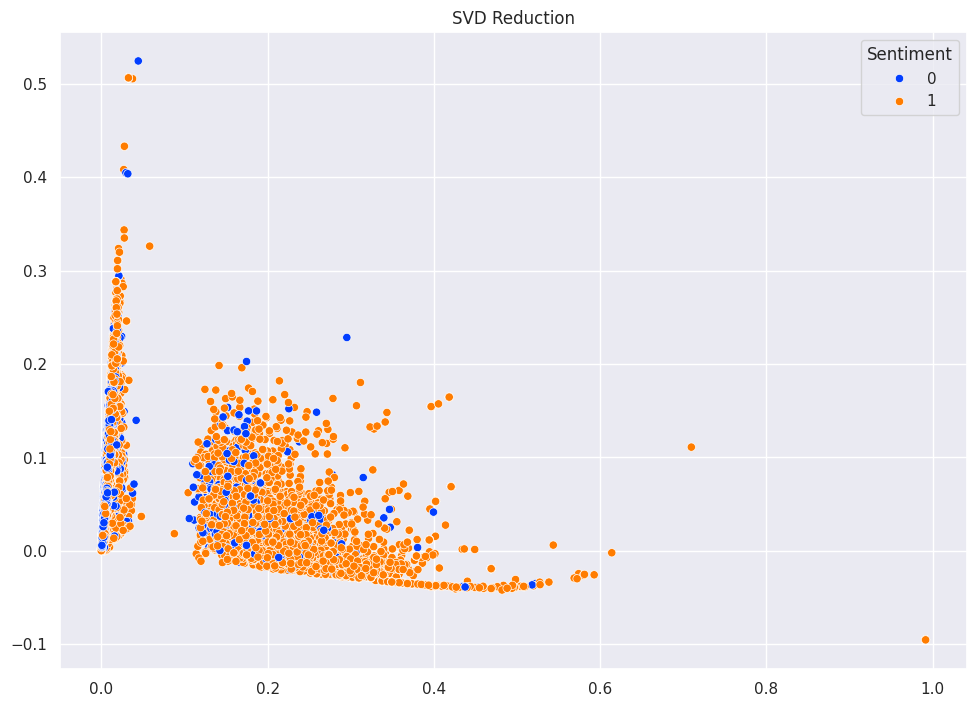

In [40]:
from sklearn.decomposition import TruncatedSVD

# Dimensionality Reduction using SVD
svd = TruncatedSVD(n_components=2, random_state=2025) # 2 components for 2D visualization
x_train_trunc = svd.fit_transform(x_train_tfidf)

plt.figure()
plt.title('SVD Reduction')
_=sns.scatterplot(x=x_train_trunc[:,0],
                y=x_train_trunc[:,1],
                hue=y_train,
                legend='full',
                palette=palette)

### **Model Training: Baseline and Logistic Regression Classifiers**

In this section, we compare three different classification approaches for tweet sentiment prediction. The aim is to evaluate how different feature representations (TF-IDF vs. Boolean presence) and model assumptions impact classification performance.

#### 1. **Majority Baseline Classifier**
The baseline model predicts the sentiment class that appears most frequently in the training set.  
This provides a **lower-bound performance benchmark**. A good classifier should significantly outperform this baseline.

#### 2. **Logistic Regression with TF-IDF and Character-Level Features**
This model uses a **hybrid feature representation**:
- **Word-level TF-IDF** features (unigrams, bigrams, trigrams)
- **Character-level n-grams** to capture stylistic cues, misspellings, slang, and emojis often found in tweets.

Additionally, we apply:
- **Feature selection using Mutual Information (`SelectKBest`)** to keep the most informative 30,000 features.
- **Class-balanced Logistic Regression** to counteract class imbalance.

This model is expected to capture both semantic and stylistic sentiment signals.

#### 3. **Logistic Regression with Boolean Bag-of-Words Features**
This model uses a **binary CountVectorizer** that records only the *presence or absence* of terms.  
This representation is simpler and may reduce noise, but it ignores term frequency and relative importance of words.

In [ ]:
# === Three Pipelines: Baseline, Logistic Regression (TF-IDF), Logistic Regression (Boolean) ===
import time
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# 1) Majority Baseline (most_frequent)
baseline = Pipeline([
    ("classifier", DummyClassifier(strategy="most_frequent", random_state=2025)),
])

# 2) Logistic Regression (TF-IDF)
vectorizer = FeatureUnion([
    ('word', TfidfVectorizer(ngram_range = (1, 3),max_features = 30000, stop_words='english', sublinear_tf = True)),
    # Character features help with misspellings, slang, and emojis.
    ('char', TfidfVectorizer(analyzer='char', ngram_range=(3,5), max_features=20000))
])

lr_tfidf = Pipeline([
    ('vectorizer', vectorizer),
    ('selector', SelectKBest(mutual_info_classif, k=30000)),
    ('classifier', LogisticRegression(max_iter=1000, n_jobs=-1, class_weight='balanced', C=1))
])

# 3) Logistic Regression (Boolean)
lr_boolean = Pipeline([
    ("vectorizer", CountVectorizer(binary=True, max_features = 30000, stop_words='english')),
    ("classifier", LogisticRegression(
        solver="lbfgs",
        penalty="l2",
        C=1.0,
        random_state=2025,
        max_iter=200,
        class_weight='balanced'
    )),
])

# Quick sanity fits + metrics
def quick_report(name, pipe, x_train, y_train, x_test, y_test):
    t0 = time.time()
    pipe.fit(x_train, y_train)
    dt = time.time() - t0
    ytr = pipe.predict(x_train)
    yte = pipe.predict(x_test)
    print(f"✓ {name} trained in {dt:.3f}s")
    print(f"  Train  Acc: {accuracy_score(y_train, ytr):.4f} | F1: {f1_score(y_train, ytr):.4f}")
    print(f"  Test   Acc: {accuracy_score(y_test, yte): .4f} | F1: {f1_score(y_test, yte): .4f}\n")
    return pipe

print("=== Evaluation ===")
baseline        = quick_report("Baseline",          baseline, x_train, y_train, x_test, y_test)
lr_tfidf        = quick_report("LR (TF-IDF)",       lr_tfidf, x_train, y_train, x_test, y_test)
lr_boolean      = quick_report("LR (Boolean)",    lr_boolean, x_train, y_train, x_test, y_test)

trained_models = [
    ("Majority Baseline", baseline),
    ("TF-IDF+LR", lr_tfidf),
    ("Boolean+LR", lr_boolean)
]


=== Evaluation ===
✓ Baseline trained in 0.009s
  Train  Acc: 0.5646 | F1: 0.7217
  Test   Acc:  0.5646 | F1:  0.7217

✓ LR (TF-IDF) trained in 632.347s
  Train  Acc: 0.8316 | F1: 0.8484
  Test   Acc:  0.7695 | F1:  0.7934

✓ LR (Boolean) trained in 3.540s
  Train  Acc: 0.8213 | F1: 0.8410
  Test   Acc:  0.7297 | F1:  0.7606



## **Non-Linear Classification with K-Nearest Neighbors (KNN)**

In addition to linear models such as Logistic Regression, we evaluate a **non-linear classifier**: the **k-Nearest Neighbors (k-NN)** algorithm. Unlike parametric models, k-NN does not learn a decision boundary during training. Instead, it classifies a new instance by comparing it to the **k most similar training samples**.

- k = num. of nearest training samples (neighbors) a new observation is compared to. The class label is predicted by **majority vote** among those K neighbors.
- Key hyperparameters / concepts:
  - `n_neighbors (k)`: number of neighbors to consider.
  - `weights`: whether all neighbors count equally or closer ones are weighted more heavily.
  - `metric`: how to measure distance/similarity between points.

This model is added to the previously trained set of classifiers and evaluated with the same metrics (Accuracy and F1-Score).  
Comparing this model with Logistic Regression allows us to understand whether **local similarity** or **global linear separation** better captures sentiment patterns in tweets.


In [31]:
# --- k-NN text classifier (TF-IDF + cosine) ---
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

knn_tfidf = Pipeline([
    ('vectorizer', vectorizer),
    ("classifier", KNeighborsClassifier(
        n_neighbors=25,          # try {5,10,25,50} later on DEV
        metric="cosine",         # better than Euclidean for text
        weights="distance",      # closer neighbors weigh more
        n_jobs=-1
    )),
])

# add to your model list and re-run the table evaluation
trained_models = [
    ("Majority Baseline", baseline),
    ("TF-IDF+LR",         lr_tfidf),
    ("Boolean+LR",        lr_boolean),
    ("TF-IDF+kNN",        knn_tfidf),
]

print("=== Evaluation ===")
knn_tfidf       = quick_report("KNN",          knn_tfidf, x_train, y_train, x_test, y_test)

=== Evaluation ===
✓ KNN trained in 19.098s
  Train  Acc: 0.9945 | F1: 0.9951
  Test   Acc:  0.7184 | F1:  0.7641



### **TF-IDF Interpretation: Identifying the Most Influential Features**

To better understand how the Logistic Regression classifier makes sentiment predictions, we extract and visualize the **most influential features** from the trained TF-IDF + Logistic Regression model.

Logistic Regression assigns a **coefficient (weight)** to each feature:
- A **positive coefficient** increases the likelihood of predicting the **positive sentiment** class.
- A **negative coefficient** increases the likelihood of predicting the **negative sentiment** class.
- The **magnitude** reflects how strongly the feature influences the prediction.

This function performs the following steps:
1. Retrieves the vocabulary features selected during TF-IDF vectorization and `SelectKBest`.
2. Extracts the learned coefficient values from the trained Logistic Regression model.
3. Sorts and displays the **top N positively-associated** and **top N negatively-associated** features.
4. Visualizes them using horizontal bar plots for clearer interpretability.

This analysis provides insight into:
- Which words or phrases are **most strongly associated** with **positive sentiment**.
- Which features are most **indicative of negative sentiment**.
- Whether these align with human intuition, confirming that the model is learning meaningful linguistic patterns.


In [ ]:
def get_top_features(pipeline, top_n=20):
    """
    Display and return the most influential features from a
    TF-IDF + SelectKBest + LogisticRegression pipeline.

    Args:
        pipeline: trained sklearn Pipeline
        top_n: number of top positive/negative features to show
    """
    # Extract steps
    vectorizer = pipeline.named_steps['vectorizer']
    selector = pipeline.named_steps['selector']
    classifier = pipeline.named_steps['classifier']

    # Get all feature names from vectorizer
    feature_names = np.array(vectorizer.get_feature_names_out())

    # Get mask of features selected by SelectKBest
    selected_mask = selector.get_support()
    selected_features = feature_names[selected_mask]

    # Get classifier coefficients
    coefs = classifier.coef_.flatten()

    # Combine features + coefficients
    feature_importance = pd.DataFrame({
        'feature': selected_features,
        'coef': coefs
    })

    # Sort by coefficient values
    top_positive = feature_importance.sort_values(by='coef', ascending=False).head(top_n)
    top_negative = feature_importance.sort_values(by='coef', ascending=True).head(top_n)

    # --- Display ---
    #print("Top Positive Features:")
    #print(top_positive.to_string(index=False))

    #print("\nTop Negative Features:")
    #print(top_negative.to_string(index=False))

    # --- Plot ---
    plt.figure(figsize=(10,6))
    plt.barh(top_positive['feature'][::-1], top_positive['coef'][::-1], color='green')
    plt.title(f"Top {top_n} Positive Features")
    plt.xlabel("Coefficient")
    plt.show()

    plt.figure(figsize=(10,6))
    plt.barh(top_negative['feature'], top_negative['coef'], color='red')
    plt.title(f"Top {top_n} Negative Features")
    plt.xlabel("Coefficient")
    plt.show()

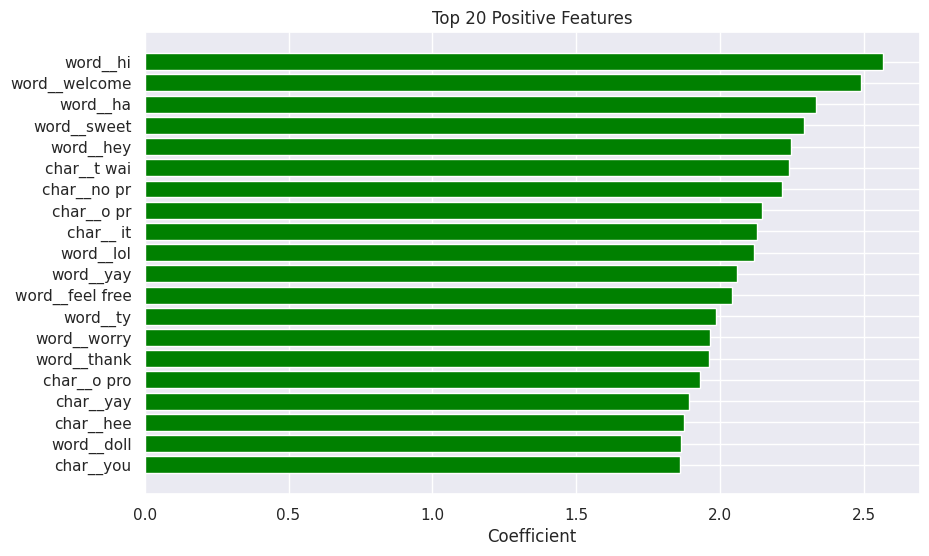

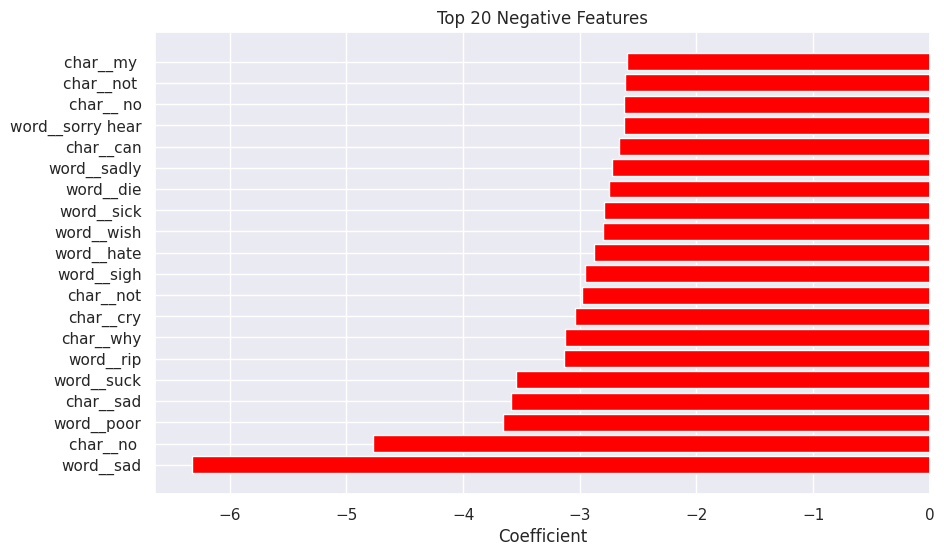

In [ ]:
get_top_features(lr_tfidf, 20)

## Evaluation

To assess the effectiveness of each sentiment classification model, we evaluate them on the **held-out test set** using two key diagnostic tools:

#### 1. **Classification Report**
This provides:
- **Precision**: How many predicted positives are truly positive.
- **Recall**: How many actual positives are correctly identified.
- **F1-Score**: Harmonic mean of precision and recall, suitable for imbalanced datasets.

Scores are reported **separately for the Negative and Positive classes**, as well as averaged.

#### 2. **Confusion Matrix**
The confusion matrix visualizes:
- Correct predictions (diagonal cells)
- Misclassifications (off-diagonal cells)

This allows us to observe:
- Whether the classifier favors one class over the other.
- Whether certain models systematically mislabel sentiment.

By comparing the baseline, Boolean Logistic Regression, TF-IDF Logistic Regression, and k-NN models, we identify:
- The performance improvements gained by richer text representations.
- The benefit of including character-level features.
- Whether non-linear similarity-based classification improves or harms generalization.

This step provides a **quantitative and visual comparison** to determine which model is best suited for the sentiment classification task.



================= Majority Baseline =================

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

    Negative     0.0000    0.0000    0.0000      6530
    Positive     0.5646    1.0000    0.7217      8469

    accuracy                         0.5646     14999
   macro avg     0.2823    0.5000    0.3609     14999
weighted avg     0.3188    0.5646    0.4075     14999

CONFUSION MATRIX:


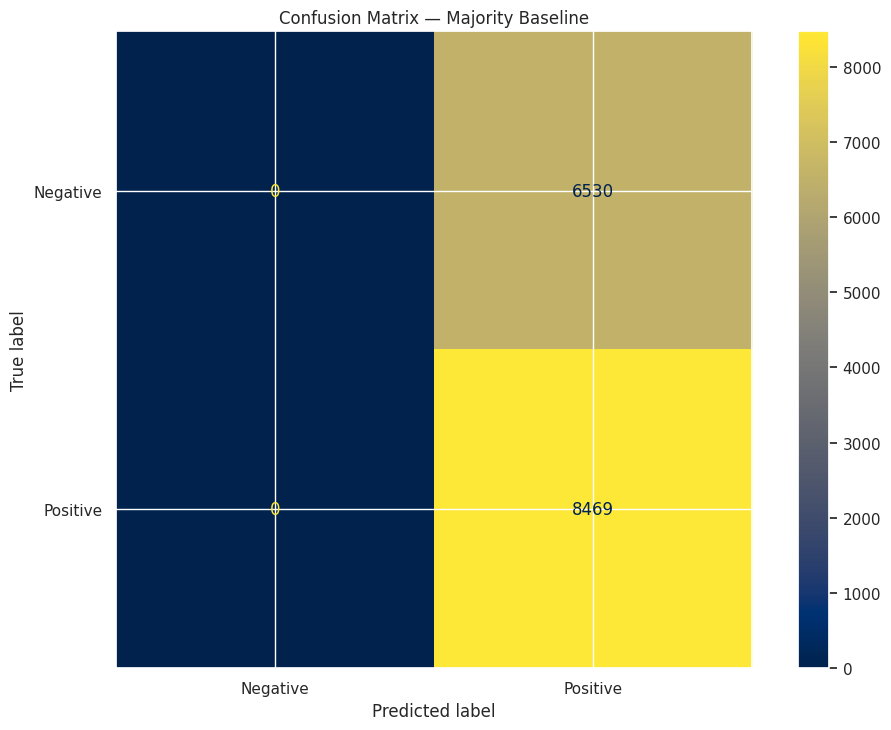


================= Boolean + Logistic Regression =================

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

    Negative     0.6895    0.6897    0.6896      6530
    Positive     0.7607    0.7605    0.7606      8469

    accuracy                         0.7297     14999
   macro avg     0.7251    0.7251    0.7251     14999
weighted avg     0.7297    0.7297    0.7297     14999

CONFUSION MATRIX:


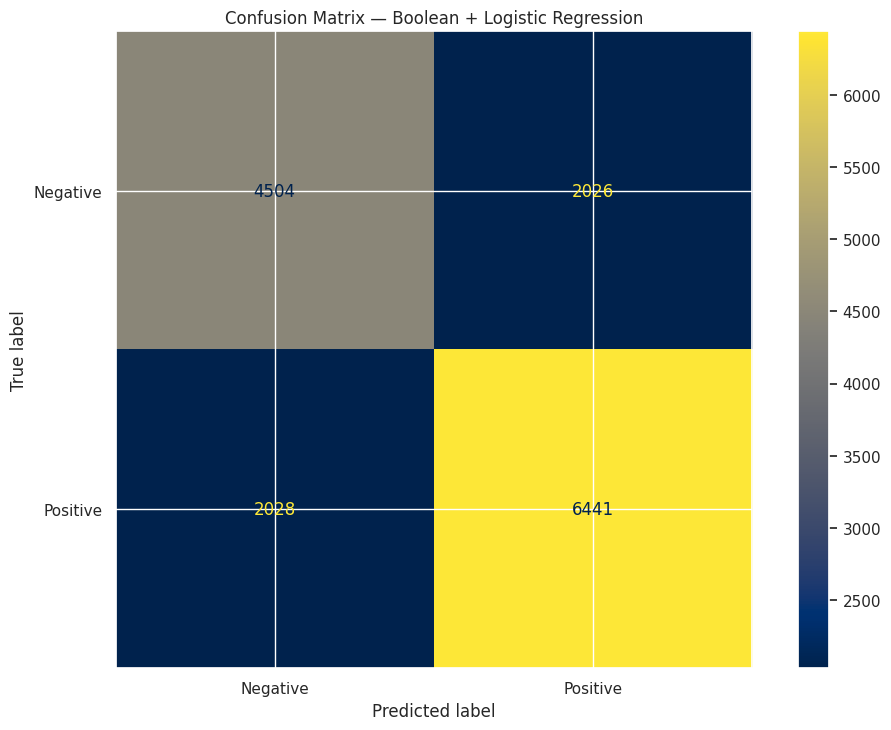


================= TF-IDF + Logistic Regression =================

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

    Negative     0.7282    0.7508    0.7394      6530
    Positive     0.8032    0.7839    0.7934      8469

    accuracy                         0.7695     14999
   macro avg     0.7657    0.7674    0.7664     14999
weighted avg     0.7705    0.7695    0.7699     14999

CONFUSION MATRIX:


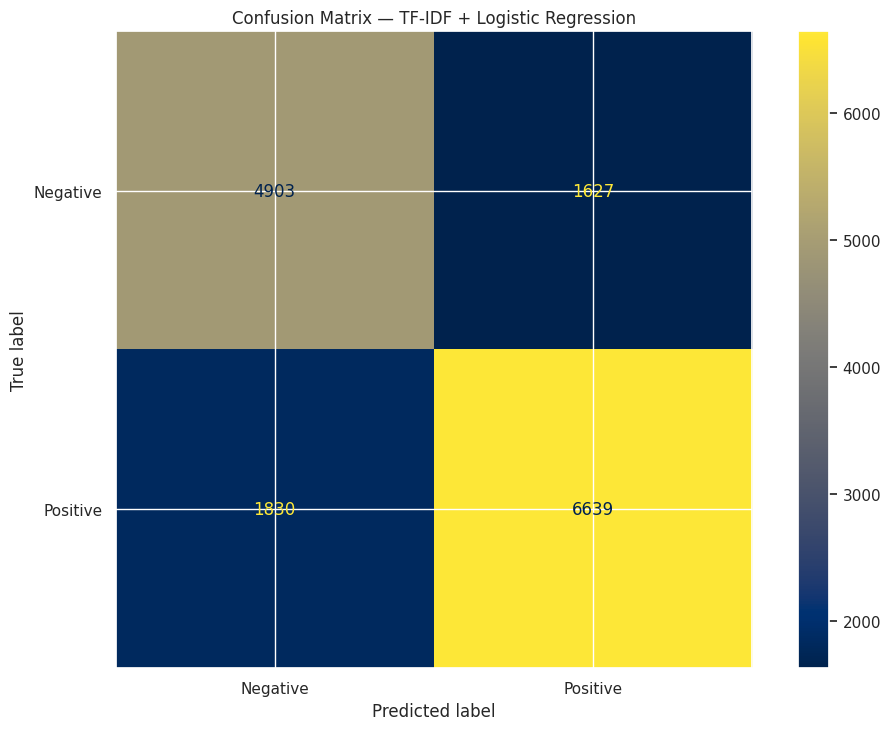


================= TF-IDF + KNN =================

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

    Negative     0.7073    0.6025    0.6507      6530
    Positive     0.7249    0.8078    0.7641      8469

    accuracy                         0.7184     14999
   macro avg     0.7161    0.7051    0.7074     14999
weighted avg     0.7172    0.7184    0.7147     14999

CONFUSION MATRIX:


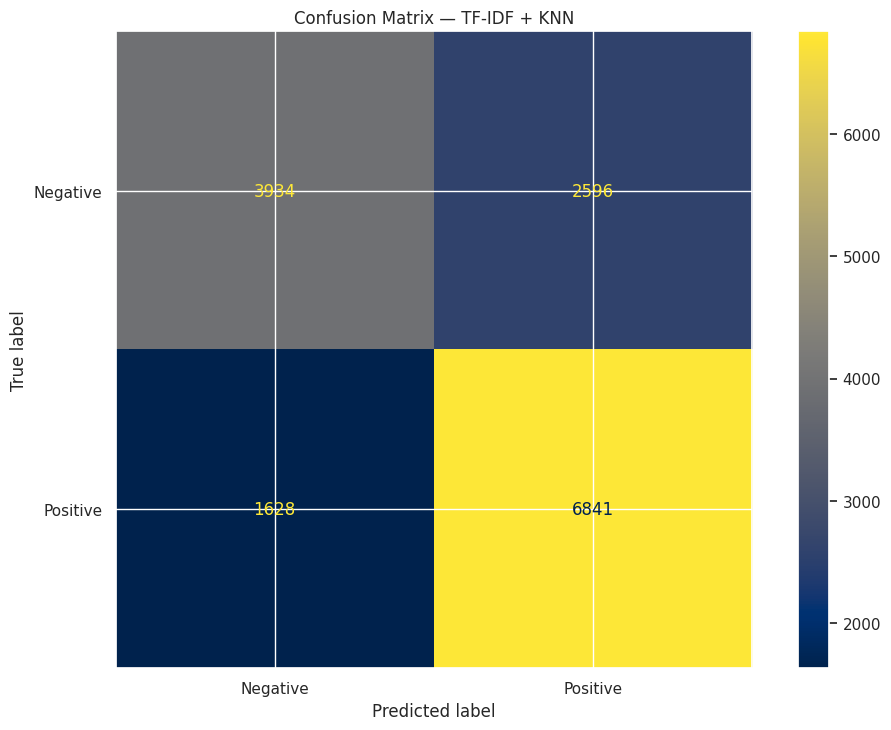

In [32]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

def evaluate_and_plot(name, model, x_test, y_test):
    print(f"\n================= {name} =================")
    y_pred = model.predict(x_test)

    # Classification Report
    print("\nCLASSIFICATION REPORT:\n")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive'], digits=4))

    # Confusion Matrix
    print("CONFUSION MATRIX:")
    _ = ConfusionMatrixDisplay.from_estimator(
        estimator=model,
        X=x_test,
        y=y_test,
        cmap='cividis',
        values_format='.0f',
        display_labels=['Negative', 'Positive']
    )
    plt.title(f'Confusion Matrix — {name}')
    plt.show()

evaluate_and_plot("Majority Baseline", baseline, x_test, y_test)
evaluate_and_plot("Boolean + Logistic Regression", lr_boolean, x_test, y_test)
evaluate_and_plot("TF-IDF + Logistic Regression", lr_tfidf, x_test, y_test)
evaluate_and_plot("TF-IDF + KNN", knn_tfidf, x_test, y_test)

While standard evaluation metrics (accuracy, F1-score, and confusion matrices) provide useful performance summaries, they do not fully capture differences in how each model treats the **positive** and **negative** sentiment classes.  
To provide a more complete analysis, we compute **per-class** performance metrics and **macro-averaged** scores across different dataset splits.

#### Metrics Computed:
For each class (Negative and Positive), we measure:
- **Precision (P):** How many predicted samples of a class are correct.
- **Recall (R):** How many true samples of a class are correctly identified.
- **F1-Score (F1):** Harmonic mean of precision and recall.
- **PR-AUC:** Area under the Precision–Recall curve for a one-vs-rest comparison.

Additionally, we compute:
- **Macro-Averaged Precision, Recall, F1, and PR-AUC**, which treat both classes equally and are robust to class imbalance.

#### Evaluation Strategy:
This evaluation is performed on:
1. **Training Set** → Indicates how well the model fits the data.
2. **Development Set** → Used for model selection and tuning.
3. **Test Set** → Measures final generalization performance.

The function `evaluate_models` trains each model once on the training data and then:
- Generates predictions,
- Computes per-class and macro metrics,
- Returns results as aligned tables for comparison.

This allows us to compare models **fairly and consistently** across all dataset splits.


In [ ]:
def per_class_prf(y_true, y_pred, label_order):
    """
    Returns dict: {label: (P,R,F1)} in the given label_order.
    """
    P, R, F1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=label_order, average=None, zero_division=0
    )
    return {lbl: (float(p), float(r), float(f1)) for lbl, p, r, f1 in zip(label_order, P, R, F1)}

def per_class_prauc(y_true, proba, label_order):
    """
    One-vs-rest PR-AUC (Average Precision) per class.
    y_true: array-like labels
    proba: np.array shape (n_samples, n_classes) with predict_proba values
    """
    y_true = np.asarray(y_true)
    ap = {}
    for j, lbl in enumerate(label_order):
        y_bin = (y_true == lbl).astype(int)
        y_score = proba[:, j]
        ap[lbl] = float(average_precision_score(y_bin, y_score))
    return ap

def evaluate_on_split(estimator, X, y, label_order, name):
    """
    Fits already done outside. Here we predict, compute per-class metrics and macro averages.
    Returns one row (dict) suitable for a DataFrame.
    """
    y_pred = estimator.predict(X)
    # we assume predict_proba exists for simplicity (it does for Dummy & LogisticRegression)
    y_proba = estimator.predict_proba(X)

    prf = per_class_prf(y, y_pred, label_order)
    ap  = per_class_prauc(y, y_proba, label_order)

    row = {"Model": name}
    per_class_vals = []
    for lbl in label_order:
        P, R, F1 = prf[lbl]
        A = ap[lbl]
        row[f"P({lbl})"]     = P
        row[f"R({lbl})"]     = R
        row[f"F1({lbl})"]    = F1
        row[f"PR-AUC({lbl})"]= A
        per_class_vals.append((P, R, F1, A))

    # macro averages from the per-class values
    macro = np.mean(per_class_vals, axis=0)
    row["Macro-P"]       = float(macro[0])
    row["Macro-R"]       = float(macro[1])
    row["Macro-F1"]      = float(macro[2])
    row["Macro-PR-AUC"]  = float(macro[3])
    return row

def evaluate_models(models, X_train, y_train, X_dev, y_dev, X_test, y_test):
    """
    Trains each model on TRAIN, then evaluates on TRAIN/DEV/TEST.
    Returns three DataFrames: train_df, dev_df, test_df with aligned columns.
    """
    train_rows, dev_rows, test_rows = [], [], []

    for name, pipe in models:
        # Fit on TRAIN only
        pipe.fit(X_train, y_train)
        # establish consistent label order from the trained classifier
        label_order = list(pipe.named_steps["classifier"].classes_)

        # compute rows for each split
        train_rows.append(evaluate_on_split(pipe, X_train, y_train, label_order, name))
        dev_rows.append(evaluate_on_split(pipe, X_dev, y_dev, label_order, name))
        test_rows.append(evaluate_on_split(pipe, X_test, y_test, label_order, name))

    # Build DataFrames with consistent column ordering:
    # Start with ["Model"], then for each label add 4 cols, then macro cols
    # Use label order from the *last* trained model (all models share the same labels)
    last_label_order = list(models[-1][1].named_steps["classifier"].classes_)
    columns = ["Model"]
    for lbl in last_label_order:
        columns += [f"P({lbl})", f"R({lbl})", f"F1({lbl})", f"PR-AUC({lbl})"]
    columns += ["Macro-P", "Macro-R", "Macro-F1", "Macro-PR-AUC"]

    train_df = pd.DataFrame(train_rows)[columns]
    dev_df   = pd.DataFrame(dev_rows)[columns]
    test_df  = pd.DataFrame(test_rows)[columns]

    return train_df, dev_df, test_df


In [33]:
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import average_precision_score

train_df, dev_df, test_df = evaluate_models(
    trained_models,
    x_train, y_train,
    x_dev, y_dev,
    x_test, y_test
)

pd.options.display.float_format = '{:.4f}'.format

print("=== TRAIN RESULTS ===")
display(train_df)

print("\n=== DEV RESULTS ===")
display(dev_df)

print("\n=== TEST RESULTS ===")
display(test_df)


=== TRAIN RESULTS ===


,Model,P(0),R(0),F1(0),PR-AUC(0),P(1),R(1),F1(1),PR-AUC(1),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Majority Baseline,0.0000,0.0000,0.0000,0.4354,0.5646,1.0000,0.7217,0.5646,0.2823,0.5000,0.3609,0.5000
1,TF-IDF+LR,0.7940,0.8281,0.8107,0.8793,0.8629,0.8344,0.8484,0.9305,0.8285,0.8312,0.8296,0.9049
2,Boolean+LR,0.7912,0.8010,0.7960,0.8632,0.8451,0.8370,0.8410,0.9160,0.8181,0.8190,0.8185,0.8896
3,TF-IDF+kNN,0.9898,0.9976,0.9937,0.9998,0.9982,0.9921,0.9951,0.9998,0.9940,0.9948,0.9944,0.9998



=== DEV RESULTS ===


,Model,P(0),R(0),F1(0),PR-AUC(0),P(1),R(1),F1(1),PR-AUC(1),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Majority Baseline,0.0000,0.0000,0.0000,0.4354,0.5646,1.0000,0.7217,0.5646,0.2823,0.5000,0.3609,0.5000
1,TF-IDF+LR,0.7220,0.7585,0.7398,0.8055,0.8062,0.7748,0.7902,0.8763,0.7641,0.7666,0.7650,0.8409
2,Boolean+LR,0.6851,0.6888,0.6870,0.7560,0.7590,0.7559,0.7575,0.8312,0.7221,0.7224,0.7222,0.7936
3,TF-IDF+kNN,0.7002,0.5977,0.6449,0.7279,0.7212,0.8027,0.7598,0.8188,0.7107,0.7002,0.7023,0.7734



=== TEST RESULTS ===


,Model,P(0),R(0),F1(0),PR-AUC(0),P(1),R(1),F1(1),PR-AUC(1),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Majority Baseline,0.0000,0.0000,0.0000,0.4354,0.5646,1.0000,0.7217,0.5646,0.2823,0.5000,0.3609,0.5000
1,TF-IDF+LR,0.7282,0.7508,0.7394,0.8103,0.8032,0.7839,0.7934,0.8760,0.7657,0.7674,0.7664,0.8431
2,Boolean+LR,0.6895,0.6897,0.6896,0.7551,0.7607,0.7605,0.7606,0.8255,0.7251,0.7251,0.7251,0.7903
3,TF-IDF+kNN,0.7073,0.6025,0.6507,0.7371,0.7249,0.8078,0.7641,0.8206,0.7161,0.7051,0.7074,0.7789


### **Learning Curves**

To assess how each classifier benefits from additional training data, we generate **learning curves** plotting the **Macro-F1 score** against progressively larger fractions of the training set.

For each fraction (from 10% to 100% of the training data):

1. A **stratified subset** of the training set is sampled to preserve class balance.
2. The model is retrained **from scratch** on this subset.
3. The **Macro-F1 score** is computed on:
   - The subset of the training set (training performance)
   - The full development set (generalization performance)

By comparing the **train** and **dev** curves, we can diagnose:

| Pattern | Interpretation |
|--------|---------------|
| **High Train F1 and Low Dev F1** | Overfitting — the model memorizes training data but generalizes poorly. |
| **Low Train and Dev F1** | Underfitting — model lacks capacity or features. |
| **Both scores increase and stabilize** | Model benefits from more data and generalizes well. |

This visualization helps determine:
- Whether more training data would improve performance.
- Which models are capacity-limited vs. data-limited.
- Whether additional regularization or feature adjustments are needed.


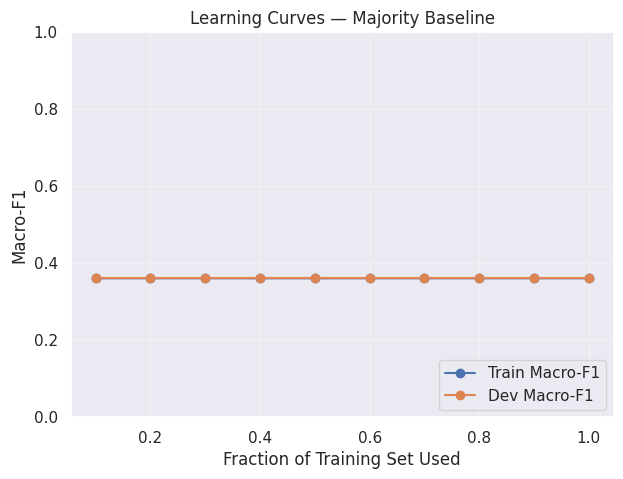

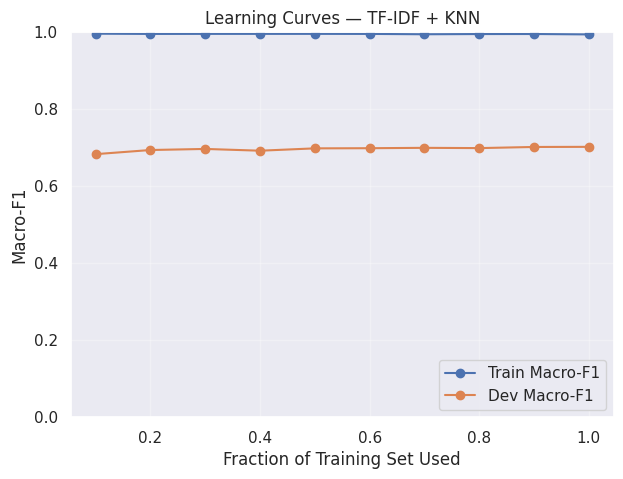

In [34]:
# === Learning curves (Macro-F1) per classifier against a fixed DEV set ===
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedShuffleSplit

# Fractions of the training set to use (include 1.0 for full-train)
FRACTIONS = np.linspace(0.1, 1.0, 10)  # 0.1, 0.2, ..., 1.0
RANDOM_STATE = 2025

def learning_curves_fixed_dev(model, name, x_train, y_train, x_dev, y_dev, fractions=FRACTIONS):
    """For each fraction of TRAIN:
       - stratified subsample (except at 1.0 → use full train),
       - fit model on that subset,
       - record Macro-F1 on the subset (train) and on the full DEV."""
    y_train = np.asarray(y_train)
    x_train_arr = np.array(x_train, dtype=object)

    train_scores, dev_scores, used_fracs = [], [], []

    for frac in fractions:
        if frac < 1.0:
            sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=RANDOM_STATE)
            (idx_sub, _), = sss.split(x_train_arr, y_train)
        else:
            # full training set
            idx_sub = np.arange(len(y_train))

        x_sub = x_train_arr[idx_sub]
        y_sub = y_train[idx_sub]

        # Fit fresh on the subset (pipelines refit vectorizer etc.)
        model.fit(x_sub, y_sub)

        # Train-subset Macro-F1
        y_sub_pred = model.predict(x_sub)
        train_f1 = f1_score(y_sub, y_sub_pred, average='macro')

        # DEV Macro-F1
        y_dev_pred = model.predict(x_dev)
        dev_f1 = f1_score(y_dev, y_dev_pred, average='macro')

        train_scores.append(train_f1)
        dev_scores.append(dev_f1)
        used_fracs.append(frac)

    # Plot
    plt.figure(figsize=(7,5))
    plt.plot(used_fracs, train_scores, marker='o', label='Train Macro-F1')
    plt.plot(used_fracs, dev_scores,   marker='o', label='Dev Macro-F1')
    plt.title(f'Learning Curves — {name}')
    plt.xlabel('Fraction of Training Set Used')
    plt.ylabel('Macro-F1')
    plt.ylim(0.0, 1.0)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='lower right')
    plt.show()

# One plot per classifier (two curves per plot)
learning_curves_fixed_dev(baseline, "Majority Baseline", x_train, y_train, x_dev, y_dev)
learning_curves_fixed_dev(knn_tfidf, "TF-IDF + KNN", x_train, y_train, x_dev, y_dev)


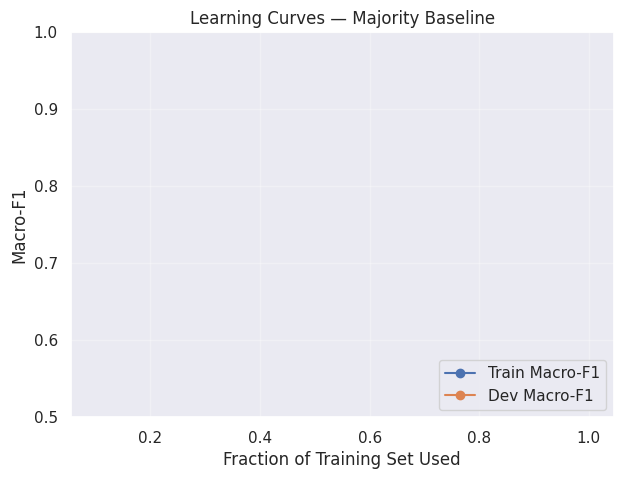

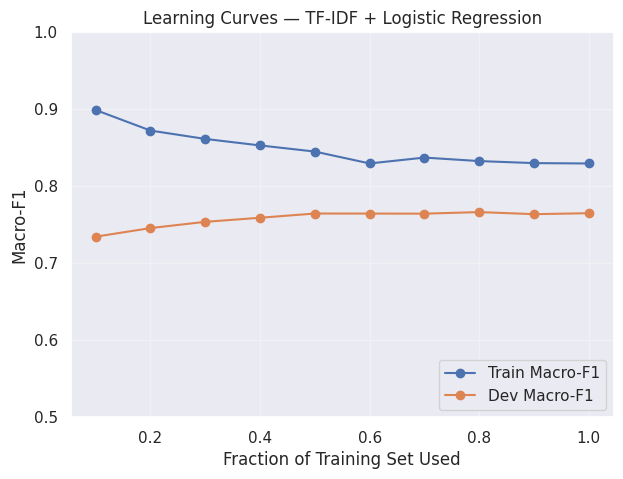

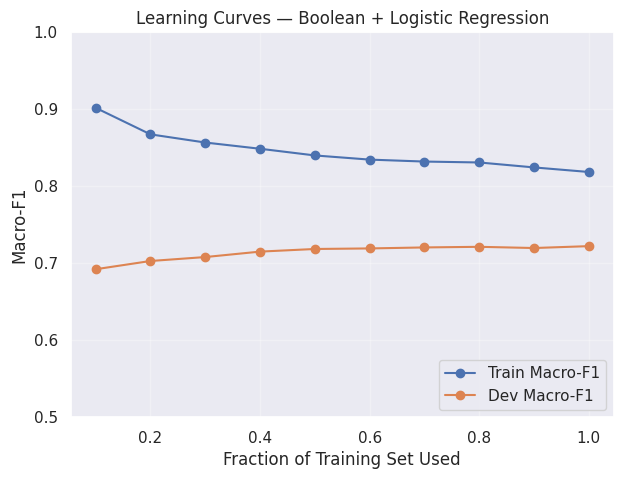

In [ ]:
# === Learning curves (Macro-F1) per classifier against a fixed DEV set ===
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedShuffleSplit

# Fractions of the training set to use (include 1.0 for full-train)
FRACTIONS = np.linspace(0.1, 1.0, 10)  # 0.1, 0.2, ..., 1.0
RANDOM_STATE = 2025

def learning_curves_fixed_dev(model, name, x_train, y_train, x_dev, y_dev, fractions=FRACTIONS):
    """For each fraction of TRAIN:
       - stratified subsample (except at 1.0 → use full train),
       - fit model on that subset,
       - record Macro-F1 on the subset (train) and on the full DEV."""
    y_train = np.asarray(y_train)
    x_train_arr = np.array(x_train, dtype=object)

    train_scores, dev_scores, used_fracs = [], [], []

    for frac in fractions:
        if frac < 1.0:
            sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=RANDOM_STATE)
            (idx_sub, _), = sss.split(x_train_arr, y_train)
        else:
            # full training set
            idx_sub = np.arange(len(y_train))

        x_sub = x_train_arr[idx_sub]
        y_sub = y_train[idx_sub]

        # Fit fresh on the subset (pipelines refit vectorizer etc.)
        model.fit(x_sub, y_sub)

        # Train-subset Macro-F1
        y_sub_pred = model.predict(x_sub)
        train_f1 = f1_score(y_sub, y_sub_pred, average='macro')

        # DEV Macro-F1
        y_dev_pred = model.predict(x_dev)
        dev_f1 = f1_score(y_dev, y_dev_pred, average='macro')

        train_scores.append(train_f1)
        dev_scores.append(dev_f1)
        used_fracs.append(frac)

    # Plot
    plt.figure(figsize=(7,5))
    plt.plot(used_fracs, train_scores, marker='o', label='Train Macro-F1')
    plt.plot(used_fracs, dev_scores,   marker='o', label='Dev Macro-F1')
    plt.title(f'Learning Curves — {name}')
    plt.xlabel('Fraction of Training Set Used')
    plt.ylabel('Macro-F1')
    plt.ylim(0.5, 1.0)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='lower right')
    plt.show()

# One plot per classifier (two curves per plot)
learning_curves_fixed_dev(baseline, "Majority Baseline", x_train, y_train, x_dev, y_dev)
learning_curves_fixed_dev(lr_tfidf,    "TF-IDF + Logistic Regression", x_train, y_train, x_dev, y_dev)
learning_curves_fixed_dev(lr_boolean,  "Boolean + Logistic Regression", x_train, y_train, x_dev, y_dev)


### Hyper-Pramenter Tuning with Grid Search (Train + Dev Split)

### **Running this code is not recommended. It takes hours to train.**

To improve the performance of the TF-IDF + Logistic Regression model, we perform **hyperparameter tuning** using `GridSearchCV`.  
Instead of using k-fold cross-validation, we apply a **predefined train–development split**, ensuring that the development set is used consistently for model selection.

#### **Parameters Tuned**
| Pipeline Component | Parameter | Values Tested | Purpose |
|-------------------|-----------|---------------|---------|
| Word-level TF-IDF | `ngram_range` | (1,2), (1,3) | Controls context captured by n-grams |
| Word-level TF-IDF | `max_features` | 20,000 or 30,000 | Vocabulary size |
| Char-level TF-IDF | `ngram_range` | (3,5), (4,6) | Sensitivity to spelling, punctuation, and stylistic cues |
| Char-level TF-IDF | `max_features` | 10,000 or 20,000 | Character-level vocabulary size |
| Feature Selector | `k` | 10,000 / 20,000 / 30,000 | Number of features retained after selection |
| Logistic Regression | `C` | 0.1, 1, 2, 3, 5 | Regularization strength (inverse λ) |

#### **Training Strategy**
- Combine **train + dev** text sets.
- Use a **`PredefinedSplit`** to ensure the original dev set is used for validation.
- Optimize using **macro F1-score**, which treats classes equally and is robust to class imbalance.

#### **Output**
After the search completes, we report:
- The **best-performing combination of hyperparameters**
- The corresponding **best cross-validation macro-F1 score**
- The final **best estimator**, stored for later evaluation and deployment.

This process allows us to systematically identify the **optimal balance** between:
- Vocabulary richness  
- Feature selection  
- Model complexity and regularization  


In [ ]:
param_grid = {
    'vectorizer__word__ngram_range': [(1,2), (1,3)],
    'vectorizer__word__max_features': [20000, 30000],
    'vectorizer__char__ngram_range': [(3,5), (4,6)],
    'vectorizer__char__max_features': [10000, 20000],
    'selector__k': [10000, 20000, 30000], # number of fetures
    'classifier__C': [0.1, 1, 2, 3, 5]   # Regulazation for the Logistic Regression c=1/λ
}

x_train_ = x_train
y_train_ = y_train

x_dev_ = x_dev
y_dev_ = y_dev

# Combine train + dev into one dataset
X_full = np.concatenate([x_train_, x_dev_])
Y_full = np.concatenate([y_train_, y_dev_])

# Define split: -1 = train, 0 = dev
split_index = [-1] * len(x_train_) + [0] * len(x_dev_)
ps = PredefinedSplit(test_fold=split_index)

# GridSearchCV using our predefined dev set
grid = GridSearchCV(
    lr_tfidf,
    param_grid=param_grid,
    cv=ps,                # use predefined train/dev split
    scoring='f1_macro',   # data is imbalanced
    n_jobs=-1,            # use all CPU cores
    verbose=2
)

print("Starting grid search...")
grid.fit(X_full, Y_full)

# Best Parameters:
# 'classifier__C': 1,
# 'selector__k': 30000,
# 'vectorizer__char__max_features': 20000,
# 'vectorizer__char__ngram_range': (3, 5),
# 'vectorizer__word__max_features': 30000,
# 'vectorizer__word__ngram_range': (1, 3)

print("\nGrid search complete!")
print("Best Parameters:", grid.best_params_)
print("Best CV Mean Accuracy:", grid.best_score_)
lr_tfidf = grid.best_estimator_

Starting grid search...
Fitting 1 folds for each of 240 candidates, totalling 240 fits


KeyboardInterrupt: 